# ⚙️ 03 — FEATURE ENGINEERING
### QM640 Capstone | Kunal Mishra

---

## What this notebook does

Takes the cleaned data from notebook 02 and **builds the features** that machine learning models will actually learn from.

Also runs **ADF stationarity tests** on every feature — a required step for any time series model.

### Features we build

| Family | Features | What they capture |
|---|---|---|
| **Target** | `Target_Dir` | Will the market go UP (1) or DOWN (0) tomorrow? |
| **Technical** | `Log_Ret_t`, `RSI_14`, `MACD_Signal`, `ATR_14` | Price momentum and volatility patterns |
| **Macro** | `VIX_Change`, `Term_Spread`, `Oil_Ret`, `Gold_Ret` | Economic conditions and global risk |
| **Fear & Greed** | `FG_Index`, `FG_Delta`, `FG_Zone` | Investor sentiment level and direction |
| **SVI** | `SVI_Market`, `SVI_Index` | Retail investor attention via search |
| **NIFTY extras** | `USDINR_Ret`, `SP500_t1_Ret`, `FG_t1_Index` | Cross-market signals (NIFTY only) |

### What is stationarity and why it matters
> A **stationary** time series has a stable mean and variance over time — it doesn't trend.  
> Machine learning models assume stationarity. If a feature trends (like a stock price),  
> the model mistakes the trend for a real signal, leading to fake good results.  
> The **ADF test** checks if a series is stationary. If it fails, we difference it once.

---
**Reads from:** `data/clean/`  
**Writes to:** `data/features/`

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Mount Drive and load config
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
warnings.filterwarnings('ignore')

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

CLEAN    = CFG['PATHS']['clean']
FEATURES = CFG['PATHS']['features']
PLOTS    = CFG['PATHS']['plots']
SEED     = CFG['SEED']
np.random.seed(SEED)

print('✅ Ready.')
print(f'   Reading from : {CLEAN}/')
print(f'   Writing to   : {FEATURES}/')

Mounted at /content/drive
✅ Ready.
   Reading from : /content/drive/MyDrive/CapstoneDA/data/clean/
   Writing to   : /content/drive/MyDrive/CapstoneDA/data/features/


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load all clean files
# ─────────────────────────────────────────────────────────────────────────────

def load(path, label):
    df = pd.read_csv(path, index_col='Date', parse_dates=['Date'])
    df.index = df.index.tz_localize(None)
    print(f'  ✅  {label:35} {len(df)} rows')
    return df

print('Loading clean data...')
sp500      = load(f'{CLEAN}/sp500_clean.csv',        'S&P 500 prices')
nifty      = load(f'{CLEAN}/nifty_clean.csv',        'NIFTY 50 prices')
macro      = load(f'{CLEAN}/macro_clean.csv',         'Macro data')
fg         = load(f'{CLEAN}/fear_greed_clean.csv',    'Fear & Greed')
svi_sp500  = load(f'{CLEAN}/svi_sp500_daily.csv',    'SVI S&P 500 (daily)')
svi_nifty  = load(f'{CLEAN}/svi_nifty_daily.csv',    'SVI NIFTY 50 (daily)')
nifty_lags = load(f'{CLEAN}/nifty_lag_features.csv', 'NIFTY lag features')
print('\nAll files loaded.')

Loading clean data...
  ✅  S&P 500 prices                      2513 rows
  ✅  NIFTY 50 prices                     2463 rows
  ✅  Macro data                          2608 rows
  ✅  Fear & Greed                        2609 rows
  ✅  SVI S&P 500 (daily)                 2513 rows
  ✅  SVI NIFTY 50 (daily)                2463 rows
  ✅  NIFTY lag features                  2609 rows

All files loaded.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Define the target variable
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Creates the column we are trying to PREDICT.
#   Target_Dir = 1 if tomorrow's close is HIGHER than today's close
#   Target_Dir = 0 if tomorrow's close is LOWER (or equal) to today's close
#
# Why binary (0/1) and not the actual return?
#   Predicting direction is a classification problem, not regression.
#   For a trader, the actionable question is: 'go long or go short tomorrow?'
#   Binary direction captures that decision cleanly.
#   Predicting exact return magnitude is much harder and less actionable.
# ─────────────────────────────────────────────────────────────────────────────

# shift(-1) means 'look at the NEXT row' — tomorrow's close
sp500['Target_Dir'] = (sp500['close'].shift(-1) > sp500['close']).astype(int)
nifty['Target_Dir'] = (nifty['close'].shift(-1) > nifty['close']).astype(int)

# Remove the last row — it has no 'next day' to predict
sp500 = sp500.iloc[:-1]
nifty = nifty.iloc[:-1]

print('Target variable created: Target_Dir')
print()
print('S&P 500 direction distribution:')
sp_counts = sp500['Target_Dir'].value_counts()
print(f'  Up days   (1): {sp_counts.get(1, 0):5}  ({sp_counts.get(1, 0)/len(sp500)*100:.1f}%)')
print(f'  Down days (0): {sp_counts.get(0, 0):5}  ({sp_counts.get(0, 0)/len(sp500)*100:.1f}%)')
print()
print('NIFTY 50 direction distribution:')
ni_counts = nifty['Target_Dir'].value_counts()
print(f'  Up days   (1): {ni_counts.get(1, 0):5}  ({ni_counts.get(1, 0)/len(nifty)*100:.1f}%)')
print(f'  Down days (0): {ni_counts.get(0, 0):5}  ({ni_counts.get(0, 0)/len(nifty)*100:.1f}%)')
print()
print('Note: If one class is much larger, this is class imbalance.')
print('We use F1 and MCC metrics (not just accuracy) to handle this.')

Target variable created: Target_Dir

S&P 500 direction distribution:
  Up days   (1):  1376  (54.8%)
  Down days (0):  1136  (45.2%)

NIFTY 50 direction distribution:
  Up days   (1):  1335  (54.2%)
  Down days (0):  1127  (45.8%)

Note: If one class is much larger, this is class imbalance.
We use F1 and MCC metrics (not just accuracy) to handle this.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Build technical indicators
# ─────────────────────────────────────────────────────────────────────────────
# What each indicator measures:
#
# Log_Ret_t = log return today = ln(today's close / yesterday's close)
#   Why log and not percentage? Log returns are additive over time and
#   don't depend on price level. They are also naturally stationary.
#
# RSI_14 = Relative Strength Index (14-day)
#   A momentum indicator from 0 to 100.
#   Above 70 = overbought (price may fall), below 30 = oversold (price may rise).
#   The '14' means we look back 14 trading days.
#
# MACD_Signal = Moving Average Convergence Divergence
#   Measures the gap between fast (12-day) and slow (26-day) exponential averages.
#   Positive = short-term momentum > long-term (bullish signal)
#   Negative = short-term momentum < long-term (bearish signal)
#
# ATR_14 = Average True Range (14-day)
#   Measures market volatility. High ATR = big price swings = uncertainty.
#   We use this as a volatility feature.
# ─────────────────────────────────────────────────────────────────────────────

def add_technical_indicators(df):
    """Add RSI, MACD, ATR, and log return to a price DataFrame."""

    c = df['close']   # shortcut for the closing price column

    # ── Log return ─────────────────────────────────────────────────────────
    df['Log_Ret_t'] = np.log(c / c.shift(1))

    # ── RSI (14-day) ───────────────────────────────────────────────────────
    delta = c.diff()                                  # daily price change
    gain  = delta.clip(lower=0)                       # keep only positive changes
    loss  = -delta.clip(upper=0)                      # keep only negative changes (as positive)
    # EWM = Exponential Weighted Moving average (recent days count more)
    avg_g = gain.ewm(span=14, min_periods=14).mean()
    avg_l = loss.ewm(span=14, min_periods=14).mean()
    rs    = avg_g / avg_l.replace(0, np.nan)          # relative strength
    df['RSI_14'] = 100 - (100 / (1 + rs))             # convert to 0-100 scale

    # ── MACD Signal line ───────────────────────────────────────────────────
    ema12       = c.ewm(span=12, min_periods=12).mean()
    ema26       = c.ewm(span=26, min_periods=26).mean()
    macd_line   = ema12 - ema26
    signal_line = macd_line.ewm(span=9, min_periods=9).mean()
    df['MACD_Signal'] = macd_line - signal_line

    # ── ATR (14-day) ───────────────────────────────────────────────────────
    # True Range = the largest of: (high-low), (|high-prev_close|), (|low-prev_close|)
    hl  = df['high'] - df['low']
    hpc = (df['high'] - c.shift(1)).abs()
    lpc = (df['low']  - c.shift(1)).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
    df['ATR_14'] = tr.ewm(span=14, min_periods=14).mean()

    return df

sp500 = add_technical_indicators(sp500)
nifty = add_technical_indicators(nifty)

print('Technical indicators added:')
print('  ✅  Log_Ret_t   — today\'s log return')
print('  ✅  RSI_14      — 14-day momentum oscillator (0-100)')
print('  ✅  MACD_Signal — trend direction signal')
print('  ✅  ATR_14      — 14-day volatility measure')
print()
print('S&P 500 sample (most recent 3 rows):')
sp500[['close', 'Log_Ret_t', 'RSI_14', 'MACD_Signal', 'ATR_14']].tail(3)

Technical indicators added:
  ✅  Log_Ret_t   — today's log return
  ✅  RSI_14      — 14-day momentum oscillator (0-100)
  ✅  MACD_Signal — trend direction signal
  ✅  ATR_14      — 14-day volatility measure

S&P 500 sample (most recent 3 rows):


,close,Log_Ret_t,RSI_14,MACD_Signal,ATR_14
Date,,,,,
2025-12-24,6932.049805,0.003216,67.766068,6.739722,61.181706
2025-12-26,6929.939941,-0.000304,67.195227,8.751019,56.246801
2025-12-29,6905.740234,-0.003498,60.455503,7.773166,54.237918


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Add macro features
# ─────────────────────────────────────────────────────────────────────────────
# What each macro feature captures:
#
# VIX_Change  = day-over-day change in the VIX fear index
#   Why change not level? The change is stationary and captures fear momentum.
#   A big jump in VIX signals sudden fear — markets often fall shortly after.
#
# Term_Spread = 10-year yield minus 2-year yield
#   Normally positive (investors demand more for longer-term risk).
#   When it goes NEGATIVE (yield curve inversion), recession often follows.
#   One of the most reliable leading indicators of recessions.
#
# Oil_Ret  = log return on Brent crude oil price
#   Oil is tightly linked to economic activity. Rising oil can signal growth
#   but also hurts inflation. Especially important for the Indian market.
#
# Gold_Ret = log return on gold price
#   Gold is a 'safe haven' — when investors are scared, they buy gold.
#   Gold rising while stocks fall = risk-off environment.
#
# USDINR_Ret = log return on USD/INR exchange rate (NIFTY models only)
#   When the Rupee weakens (USDINR rises), it often hurts Indian stocks
#   because foreign investors lose money in USD terms.
# ─────────────────────────────────────────────────────────────────────────────

def add_macro_features(df, macro_df, include_usdinr=False):
    """Attach macro features to a market DataFrame."""

    # Align macro data to the market's trading calendar using forward-fill
    m = macro_df.reindex(df.index, method='ffill')

    df['VIX_Change']  = m['VIX'].diff()
    df['Term_Spread'] = m['US10Y'] - m['US2Y']
    df['Oil_Ret']     = np.log(m['BRENT'] / m['BRENT'].shift(1))
    df['Gold_Ret']    = np.log(m['GOLD']  / m['GOLD'].shift(1))

    if include_usdinr and 'USDINR' in m.columns:
        df['USDINR_Ret'] = np.log(m['USDINR'] / m['USDINR'].shift(1))

    return df

sp500 = add_macro_features(sp500, macro, include_usdinr=False)
nifty = add_macro_features(nifty, macro, include_usdinr=True)   # NIFTY gets USDINR

print('Macro features added:')
print('  ✅  VIX_Change   — change in market fear index')
print('  ✅  Term_Spread  — yield curve (10Y - 2Y)')
print('  ✅  Oil_Ret      — Brent crude daily log return')
print('  ✅  Gold_Ret     — Gold price daily log return')
print('  ✅  USDINR_Ret   — USD/INR daily log return (NIFTY only)')

Macro features added:
  ✅  VIX_Change   — change in market fear index
  ✅  Term_Spread  — yield curve (10Y - 2Y)
  ✅  Oil_Ret      — Brent crude daily log return
  ✅  Gold_Ret     — Gold price daily log return
  ✅  USDINR_Ret   — USD/INR daily log return (NIFTY only)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Add Fear & Greed features
# ─────────────────────────────────────────────────────────────────────────────

def add_fg_features(df, fg_df):
    """Attach Fear & Greed features to a market DataFrame."""
    fg_aligned = fg_df.reindex(df.index, method='ffill')
    df['FG_Index'] = fg_aligned['FG_Index']
    df['FG_Delta'] = fg_aligned['FG_Delta']
    df['FG_Zone']  = fg_aligned['FG_Zone']
    return df

sp500 = add_fg_features(sp500, fg)
nifty = add_fg_features(nifty, fg)

print('Fear & Greed features added:')
print('  ✅  FG_Index — raw daily score (0-100)')
print('  ✅  FG_Delta — day-over-day change in score')
print('  ✅  FG_Zone  — ordinal zone (1=Extreme Fear, 5=Extreme Greed)')

Fear & Greed features added:
  ✅  FG_Index — raw daily score (0-100)
  ✅  FG_Delta — day-over-day change in score
  ✅  FG_Zone  — ordinal zone (1=Extreme Fear, 5=Extreme Greed)


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Add SVI features (with 30-day rolling z-score normalisation)
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Attaches the Google Trends SVI columns to each market DataFrame.
#   We reduce all keyword columns to TWO representative features:
#     SVI_Market = the 'share market / stock market' keyword SVI
#     SVI_Index  = the specific index keyword SVI ('S&P 500' or 'NIFTY')
#
# Why z-score normalisation?
#   Search trends change over 10 years. 'Stock market' was searched far more
#   in 2020 (COVID crash) than in 2016. If we use raw SVI values, the model
#   might think 2020 is always a period of high attention — but that was a one-off.
#   A 30-day rolling z-score normalises each value relative to the recent
#   30 trading days. So a score of +2 means 'much higher than the recent average',
#   regardless of what year it is.
# ─────────────────────────────────────────────────────────────────────────────

def add_svi_features(df, svi_df, market_keyword, index_keyword):
    """
    Attach SVI features and apply 30-day rolling z-score normalisation.
    market_keyword: the 'stock market / share market' keyword column
    index_keyword:  the specific index keyword column ('S&P 500' or 'NIFTY')
    """

    # Align SVI to the market's trading calendar
    svi_aligned = svi_df.reindex(df.index, method='ffill')

    for feature_name, keyword in [('SVI_Market', market_keyword), ('SVI_Index', index_keyword)]:
        if keyword in svi_aligned.columns:
            raw = svi_aligned[keyword]

            # 30-day rolling mean and standard deviation
            roll_mean = raw.rolling(30, min_periods=10).mean()
            roll_std  = raw.rolling(30, min_periods=10).std()
            roll_std  = roll_std.replace(0, np.nan)   # avoid division by zero

            # z-score: (value - mean) / std
            # Result: 0 = average, +2 = 2 standard deviations above average
            df[feature_name] = (raw - roll_mean) / roll_std
        else:
            # If the keyword column doesn't exist, use mean of all columns
            raw = svi_aligned.mean(axis=1)
            roll_mean = raw.rolling(30, min_periods=10).mean()
            roll_std  = raw.rolling(30, min_periods=10).std().replace(0, np.nan)
            df[feature_name] = (raw - roll_mean) / roll_std

    return df

# S&P 500 — US keywords
sp500 = add_svi_features(
    sp500, svi_sp500,
    market_keyword = CFG['SVI_KEYWORDS_SP500'][0],   # 'stock market'
    index_keyword  = CFG['SVI_KEYWORDS_SP500'][1]    # 'S&P 500'
)

# NIFTY 50 — India keywords
nifty = add_svi_features(
    nifty, svi_nifty,
    market_keyword = CFG['SVI_KEYWORDS_NIFTY'][0],   # 'share market'
    index_keyword  = CFG['SVI_KEYWORDS_NIFTY'][1]    # 'NIFTY'
)

print('SVI features added (with 30-day rolling z-score normalisation):')
print('  ✅  SVI_Market — normalised search intensity for market keyword')
print('  ✅  SVI_Index  — normalised search intensity for index-specific keyword')

SVI features added (with 30-day rolling z-score normalisation):
  ✅  SVI_Market — normalised search intensity for market keyword
  ✅  SVI_Index  — normalised search intensity for index-specific keyword


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Add NIFTY-only lag features (Global Clock Protocol)
# ─────────────────────────────────────────────────────────────────────────────

nifty_lags_aligned = nifty_lags.reindex(nifty.index, method='ffill')
nifty['SP500_t1_Ret'] = nifty_lags_aligned['SP500_t1_Ret']
nifty['FG_t1_Index']  = nifty_lags_aligned['FG_t1_Index']

print('NIFTY-only lag features added (from Global Clock Protocol):')
print('  ✅  SP500_t1_Ret — previous day S&P 500 return (leading indicator for NIFTY)')
print('  ✅  FG_t1_Index  — previous day Fear & Greed score')
print()
print('These features DO NOT appear in S&P 500 models — only NIFTY 50 models.')

NIFTY-only lag features added (from Global Clock Protocol):
  ✅  SP500_t1_Ret — previous day S&P 500 return (leading indicator for NIFTY)
  ✅  FG_t1_Index  — previous day Fear & Greed score

These features DO NOT appear in S&P 500 models — only NIFTY 50 models.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — ADF Stationarity Test on all features
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Runs the Augmented Dickey-Fuller (ADF) test on every feature.
#   If a feature FAILS (p-value >= 0.05), it means the feature is trending
#   and we need to difference it once (subtract yesterday's value from today's).
#
# The ADF test null hypothesis:
#   H0: The series is NOT stationary (it has a unit root / trend)
#   If p < 0.05 → reject H0 → series IS stationary → PASS
#   If p >= 0.05 → fail to reject H0 → series is NOT stationary → DIFFERENCE
# ─────────────────────────────────────────────────────────────────────────────

def adf_test(series, alpha=0.05):
    """Run ADF test on a series. Returns dict with result."""
    s = series.dropna()
    if len(s) < 30:
        return {'pass': None, 'pvalue': None, 'action': 'skip (too short)'}
    try:
        # maxlag=None lets ADF choose optimal lag automatically
        stat, pval, _, _, _, _ = adfuller(s, autolag='AIC')
        passed = pval < alpha
        return {
            'pass'   : passed,
            'pvalue' : round(pval, 4),
            'stat'   : round(stat, 3),
            'action' : 'PASS' if passed else 'DIFFERENCE'
        }
    except Exception as e:
        return {'pass': None, 'pvalue': None, 'action': f'error: {e}'}

# Define all features to test (exclude target and raw price columns)
SP500_FEATURES = [
    'Log_Ret_t', 'RSI_14', 'MACD_Signal', 'ATR_14',
    'VIX_Change', 'Term_Spread', 'Oil_Ret', 'Gold_Ret',
    'FG_Index', 'FG_Delta', 'FG_Zone',
    'SVI_Market', 'SVI_Index'
]
NIFTY_FEATURES = SP500_FEATURES + ['USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Index']

def run_adf_audit(df, feature_list, market_label):
    """Run ADF on all features and return a summary table."""
    results = []
    for col in feature_list:
        if col not in df.columns:
            continue
        res = adf_test(df[col])
        results.append({
            'Feature': col,
            'p-value': res.get('pvalue', '—'),
            'Stationary': '✅ YES' if res.get('pass') else '❌ NO' if res.get('pass') is False else '—',
            'Action': res.get('action', '—')
        })
    report = pd.DataFrame(results)
    print(f'\n── ADF Results: {market_label} ──')
    print(report.to_string(index=False))
    n_diff = (report['Action'] == 'DIFFERENCE').sum()
    print(f'\n  → {n_diff} feature(s) need differencing.')
    return report

adf_sp500 = run_adf_audit(sp500, SP500_FEATURES, 'S&P 500')
adf_nifty = run_adf_audit(nifty, NIFTY_FEATURES, 'NIFTY 50')


── ADF Results: S&P 500 ──
    Feature  p-value Stationary     Action
  Log_Ret_t   0.0000      ✅ YES       PASS
     RSI_14   0.0000      ✅ YES       PASS
MACD_Signal   0.0000      ✅ YES       PASS
     ATR_14   0.0000      ✅ YES       PASS
 VIX_Change   0.0000      ✅ YES       PASS
Term_Spread   0.4409          — DIFFERENCE
    Oil_Ret   0.0000      ✅ YES       PASS
   Gold_Ret   0.0000      ✅ YES       PASS
   FG_Index   0.7172          — DIFFERENCE
   FG_Delta   0.0000      ✅ YES       PASS
    FG_Zone   0.3824          — DIFFERENCE
 SVI_Market   0.0000      ✅ YES       PASS
  SVI_Index   0.0000      ✅ YES       PASS

  → 3 feature(s) need differencing.

── ADF Results: NIFTY 50 ──
     Feature  p-value Stationary     Action
   Log_Ret_t   0.0000      ✅ YES       PASS
      RSI_14   0.0000      ✅ YES       PASS
 MACD_Signal   0.0000      ✅ YES       PASS
      ATR_14   0.0002      ✅ YES       PASS
  VIX_Change   0.0000      ✅ YES       PASS
 Term_Spread   0.4419          — DIFFERE

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Apply differencing to non-stationary features
# ─────────────────────────────────────────────────────────────────────────────
# What differencing means:
#   If RSI is not stationary, we replace it with ΔRSI = today's RSI - yesterday's RSI.
#   This removes the trend and makes the series fluctuate around zero.
#   The model then learns from the CHANGE in RSI, not the level.
# ─────────────────────────────────────────────────────────────────────────────

def apply_differencing(df, adf_report):
    """Difference any features that failed the ADF test."""
    df = df.copy()
    differenced = []
    for _, row in adf_report.iterrows():
        if row['Action'] == 'DIFFERENCE' and row['Feature'] in df.columns:
            df[row['Feature']] = df[row['Feature']].diff()
            differenced.append(row['Feature'])
    if differenced:
        print(f'  Differenced: {differenced}')
    else:
        print('  No features needed differencing. ✅')
    df.dropna(inplace=True)   # differencing creates one NaN at the start
    return df

print('Applying differencing where needed...')
print('S&P 500:')
sp500_feat = apply_differencing(sp500, adf_sp500)
print('NIFTY 50:')
nifty_feat = apply_differencing(nifty, adf_nifty)

print()
print(f'Final feature matrix sizes:')
print(f'  S&P 500 : {sp500_feat.shape[0]} rows  ×  {sp500_feat.shape[1]} columns')
print(f'  NIFTY 50: {nifty_feat.shape[0]} rows  ×  {nifty_feat.shape[1]} columns')

Applying differencing where needed...
S&P 500:
  Differenced: ['Term_Spread', 'FG_Index', 'FG_Zone']
NIFTY 50:
  Differenced: ['Term_Spread', 'FG_Index', 'FG_Zone', 'FG_t1_Index']

Final feature matrix sizes:
  S&P 500 : 2479 rows  ×  19 columns
  NIFTY 50: 2358 rows  ×  22 columns


In [11]:
dfsp500=sp500
nan_by_year = dfsp500.groupby(dfsp500.index.year).apply(lambda x: x.isna().sum())
nan_by_year.T

Date,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
open,0,0,0,0,0,0,0,0,0,0
high,0,0,0,0,0,0,0,0,0,0
low,0,0,0,0,0,0,0,0,0,0
close,0,0,0,0,0,0,0,0,0,0
volume,0,0,0,0,0,0,0,0,0,0
Target_Dir,0,0,0,0,0,0,0,0,0,0
Log_Ret_t,1,0,0,0,0,0,0,0,0,0
RSI_14,14,0,0,0,0,0,0,0,0,0
MACD_Signal,33,0,0,0,0,0,0,0,0,0
ATR_14,13,0,0,0,0,0,0,0,0,0


In [12]:

dfnifty=nifty
nan_by_year = dfnifty.groupby(dfnifty.index.year).apply(lambda x: x.isna().sum())
nan_by_year.T

Date,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
open,0,0,0,0,0,0,0,0,0,0
high,0,0,0,0,0,0,0,0,0,0
low,0,0,0,0,0,0,0,0,0,0
close,0,0,0,0,0,0,0,0,0,0
volume,0,0,0,0,0,0,0,0,0,0
Target_Dir,0,0,0,0,0,0,0,0,0,0
Log_Ret_t,1,0,0,0,0,0,0,0,0,0
RSI_14,14,0,0,0,0,0,0,0,0,0
MACD_Signal,33,0,0,0,0,0,0,0,0,0
ATR_14,13,0,0,0,0,0,0,0,0,0


In [13]:
sp500

,open,high,low,close,volume,Target_Dir,Log_Ret_t,RSI_14,MACD_Signal,ATR_14,VIX_Change,Term_Spread,Oil_Ret,Gold_Ret,FG_Index,FG_Delta,FG_Zone,SVI_Market,SVI_Index
Date,,,,,,,,,,,,,,,,,,,
2016-01-04,2038.199951,2038.199951,1989.680054,2012.660034,4304880000,1,NaN,NaN,NaN,NaN,NaN,1.22,NaN,NaN,50,0.0,3,NaN,NaN
2016-01-05,2013.780029,2021.939941,2004.170044,2016.709961,3706620000,0,0.002010,NaN,NaN,NaN,-1.36,1.21,-0.020045,0.003065,51,1.0,3,NaN,NaN
2016-01-06,2011.709961,2011.709961,1979.050049,1990.260010,4336660000,0,-0.013202,NaN,NaN,NaN,1.25,1.19,-0.048101,0.012441,53,2.0,3,NaN,NaN
2016-01-07,1985.319946,1985.319946,1938.829956,1943.089966,5076590000,0,-0.023986,NaN,NaN,NaN,4.40,1.20,-0.009487,0.014366,53,0.0,3,NaN,NaN
2016-01-08,1945.969971,1960.400024,1918.459961,1922.030029,4664940000,1,-0.010898,NaN,NaN,NaN,2.02,1.19,-0.058263,-0.008978,53,0.0,3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,6865.209961,6882.029785,6855.740234,6878.490234,4465030000,1,0.006416,61.054244,-2.755822,69.229457,-0.83,0.73,0.014081,0.018897,100,0.0,5,0.006063,-1.820052
2025-12-23,6872.410156,6910.879883,6868.810059,6909.790039,3820560000,1,0.004540,65.051346,2.408559,65.608173,-0.08,0.70,0.023508,0.008558,100,0.0,5,-0.015267,-1.666605
2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,0,0.003216,67.766068,6.739722,61.181706,-0.53,0.68,0.000000,-0.000491,100,0.0,5,-0.036925,-1.536951


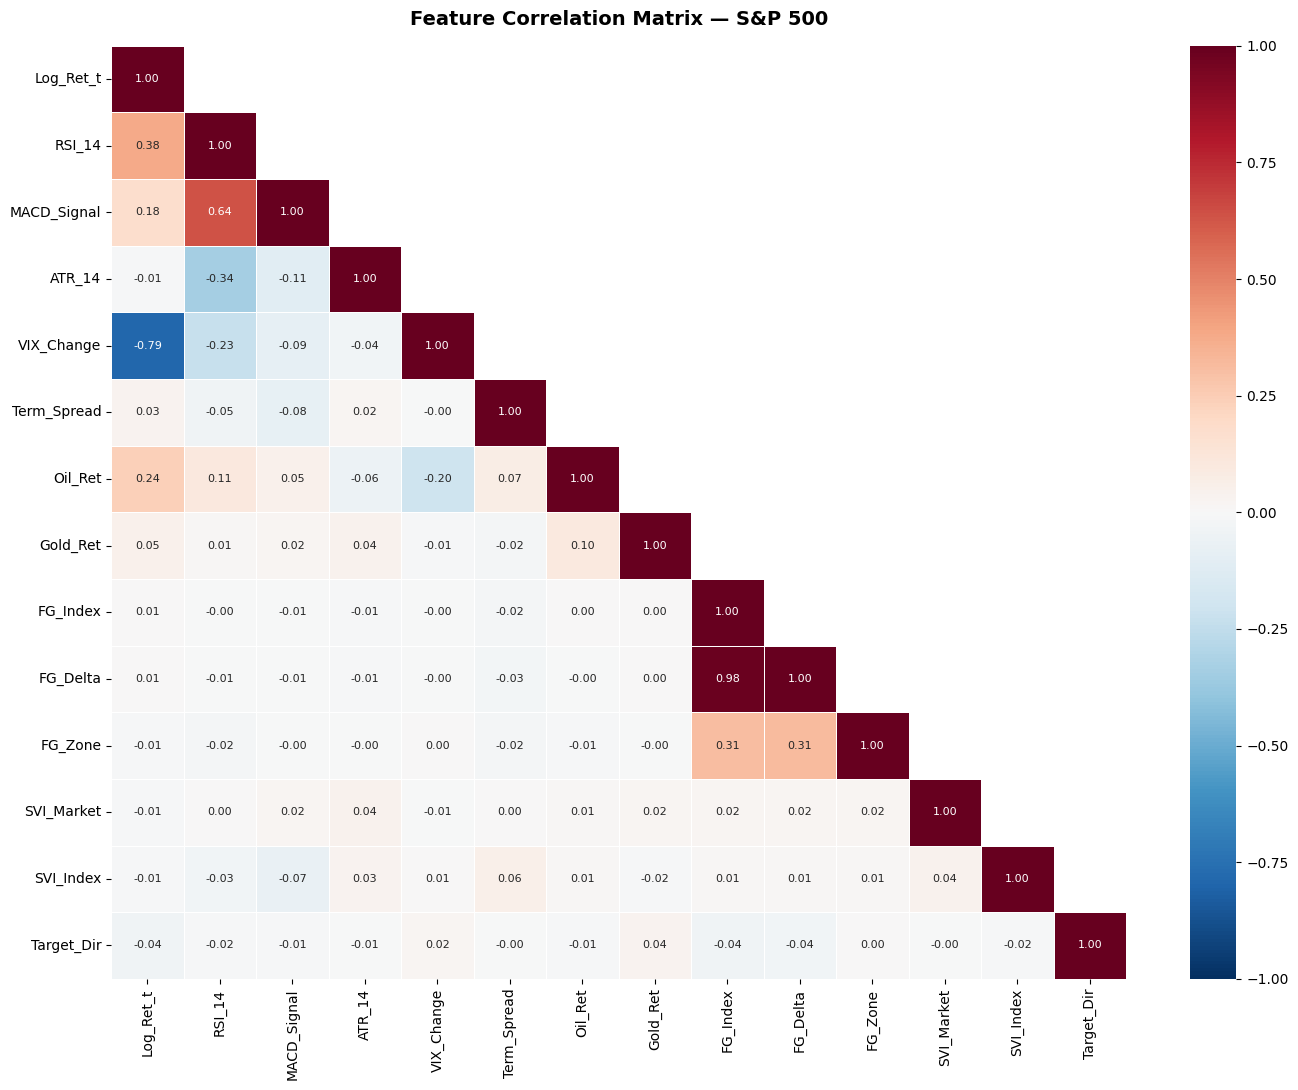


Feature correlations with Target_Dir (highest to lowest):
  FG_Index            -  -0.041
  Log_Ret_t           -  -0.040
  Gold_Ret            +  +0.036
  FG_Delta            -  -0.036
  VIX_Change          +  +0.020
  SVI_Index           -  -0.015
  RSI_14              -  -0.015
  Oil_Ret             -  -0.014
  MACD_Signal         -  -0.012
  ATR_14              -  -0.006
  SVI_Market          -  -0.003
  FG_Zone             +  +0.002
  Term_Spread         -  -0.001


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Correlation heatmap (feature relationships)
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   A heatmap shows how correlated features are with each other.
#   Deep red = strong positive correlation. Deep blue = strong negative.
#   We check the last column (Target_Dir) to see which features correlate
#   most with the direction prediction.
# ─────────────────────────────────────────────────────────────────────────────

feat_cols_sp500 = [f for f in SP500_FEATURES if f in sp500_feat.columns] + ['Target_Dir']
corr_sp500 = sp500_feat[feat_cols_sp500].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_sp500, dtype=bool), k=1)   # hide upper triangle
sns.heatmap(
    corr_sp500, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Matrix — S&P 500', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{PLOTS}/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Show which features correlate most with Target_Dir
target_corr = corr_sp500['Target_Dir'].drop('Target_Dir').sort_values(key=abs, ascending=False)
print('\nFeature correlations with Target_Dir (highest to lowest):')
for feat, corr in target_corr.items():
    bar = '█' * int(abs(corr) * 20)
    direction = '+' if corr >= 0 else '-'
    print(f'  {feat:18}  {direction}{bar}  {corr:+.3f}')

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Save feature matrices to Google Drive
# ─────────────────────────────────────────────────────────────────────────────

# Save full feature matrices
sp500_feat.to_csv(f'{FEATURES}/sp500_features.csv')
nifty_feat.to_csv(f'{FEATURES}/nifty_features.csv')

# Save the feature lists so later notebooks know which columns to use
feature_registry = {
    'sp500_all_features' : SP500_FEATURES,
    'nifty_all_features' : NIFTY_FEATURES,
    'baseline_features'  : CFG['FEATURE_FAMILIES']['technical'] + CFG['FEATURE_FAMILIES']['macro'],
    'alt_data_features'  : CFG['FEATURE_FAMILIES']['fear_greed'] + CFG['FEATURE_FAMILIES']['svi'],
    'target_column'      : 'Target_Dir',
}
with open(f'{FEATURES}/feature_registry.json', 'w') as f:
    json.dump(feature_registry, f, indent=2)

# Save ADF audit results
adf_sp500.to_csv(f'{FEATURES}/adf_audit_sp500.csv', index=False)
adf_nifty.to_csv(f'{FEATURES}/adf_audit_nifty.csv', index=False)

print('Files saved to data/features/:')
print(f'  ✅  sp500_features.csv     ({len(sp500_feat)} rows × {len(sp500_feat.columns)} columns)')
print(f'  ✅  nifty_features.csv     ({len(nifty_feat)} rows × {len(nifty_feat.columns)} columns)')
print(f'  ✅  feature_registry.json  (lists all feature groups)')
print(f'  ✅  adf_audit_sp500.csv')
print(f'  ✅  adf_audit_nifty.csv')
print()
print('─' * 55)
print('  Next step → open  04_FEATURE_SELECTION.ipynb')
print('─' * 55)

Files saved to data/features/:
  ✅  sp500_features.csv     (2479 rows × 19 columns)
  ✅  nifty_features.csv     (2358 rows × 22 columns)
  ✅  feature_registry.json  (lists all feature groups)
  ✅  adf_audit_sp500.csv
  ✅  adf_audit_nifty.csv

───────────────────────────────────────────────────────
  Next step → open  04_FEATURE_SELECTION.ipynb
───────────────────────────────────────────────────────
